#### Decision tree classification with 'features.pkl'
This notebook tests the effectiveness of predicting with 'features.pkl' and Decision tree classifier
- Split and scale dataset
- Train decision tree classifier using features.pkl dataset to determine the hyperparameters that maximize profit function
 -Make predictions to analyse the importance of each feature
- Determine the hyperparameters that maximize profit function using the most significant features
- Save the trained model
- Create a report showing dataset used, hyperparameters tested and results

In [1]:
import yaml 
import sys
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/data/')
from make_dataset import *
sys.path.append('C:/Users/inesm/projectos/tennis-predictor/src/models/')
from train_model import *
import pandas as pd
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.inspection import permutation_importance
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import shap
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier

0.9


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
interim_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/interim/'
processed_filepath = 'C:/Users/inesm/projectos/tennis-predictor/data/processed/'

with open('C:/Users/inesm/projectos/tennis-predictor/conf/conf.yaml', 'r') as config_file:
    conf = yaml.safe_load(config_file)

In [3]:
model = 'decision-tree'
today_date = datetime.now().strftime('%Y-%m-%d-%H%M') 

# Save configs tested and results in an HTML report
report_path = '../features-classified-{}-training-report-{}.html'.format(model, today_date)

In [4]:
dataset = load_data(processed_filepath, file_name='features.pkl')
dataset.describe()

,match_id,RankP1,RankP2,Surface_Carpet,Surface_Clay,Surface_Grass,Surface_Hard,OddP1,OddP2,H2H,Y_B365,winner_is_p1,Rank_dif,Odd_dif
count,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000,32375.000000
mean,19260.113668,43.577328,90.125251,0.032340,0.316139,0.112278,0.539243,1.390174,3.696084,0.326208,0.678425,0.703166,-57.920062,-2.305910
std,9990.255185,42.930227,63.329665,0.176904,0.464975,0.315713,0.498465,0.223505,2.086364,1.267710,0.111162,0.456870,119.343701,2.275397
min,1371.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.830000,-10.000000,0.147059,0.000000,-1778.000000,-9.000000
25%,10697.500000,13.000000,45.000000,0.000000,0.000000,0.000000,0.000000,1.200000,2.250000,0.000000,0.589005,0.000000,-74.000000,-3.130000
50%,19393.000000,31.000000,75.000000,0.000000,0.000000,0.000000,1.000000,1.390000,2.870000,0.000000,0.662651,1.000000,-35.000000,-1.490000
75%,27902.500000,61.000000,115.000000,0.000000,1.000000,0.000000,1.000000,1.570000,4.330000,1.000000,0.766284,1.000000,-10.000000,-0.680000
max,36362.000000,250.000000,250.000000,1.000000,1.000000,1.000000,1.000000,1.909000,10.000000,16.000000,0.906618,1.000000,1059.000000,0.000000


In [14]:
y = dataset['winner_is_p1']
features = conf['features']

# add auxiliar data for optimization function (custom scorer)
features.extend(['OddP2'])
X_and_aux_data = dataset[features]

X_and_aux_data

In [16]:
X_train_and_aux_data, X_val_and_aux_data, X_test_and_aux_data, y_train, y_val, y_test = split_data(X_and_aux_data, y)

X_train = X_train_and_aux_data.drop(['OddP2'], axis=1)
X_val = X_val_and_aux_data.drop(['OddP2'], axis=1)
X_test = X_test_and_aux_data.drop(['OddP2'], axis=1)

X_train.describe()

,OddP1,RankP1,Rank_dif,H2H,RankP2
count,25900.000000,25900.000000,25900.000000,25900.000000,25900.000000
mean,1.390172,43.533784,-57.820541,0.329112,89.966757
std,0.223523,43.015291,119.608635,1.275463,63.393279
min,1.000000,1.000000,-1778.000000,-10.000000,1.000000
25%,1.200000,13.000000,-74.000000,0.000000,45.000000
50%,1.390000,31.000000,-35.000000,0.000000,74.000000
75%,1.570000,61.000000,-10.000000,1.000000,115.000000
max,1.909000,250.000000,1059.000000,15.000000,250.000000


In [17]:
X_val.describe()

,OddP1,RankP1,Rank_dif,H2H,RankP2
count,3237.000000,3237.000000,3237.000000,3237.000000,3237.000000
mean,1.388906,43.698177,-57.777572,0.306457,91.030893
std,0.223545,43.662722,117.643729,1.276390,63.559791
min,1.000000,1.000000,-1711.000000,-6.000000,1.000000
25%,1.200000,12.000000,-77.000000,0.000000,46.000000
50%,1.380000,31.000000,-36.000000,0.000000,75.000000
75%,1.570000,62.000000,-10.000000,0.000000,117.000000
max,1.900000,250.000000,655.000000,16.000000,250.000000


In [18]:
X_test.describe()

,OddP1,RankP1,Rank_dif,H2H,RankP2
count,3238.000000,3238.000000,3238.000000,3238.00000,3238.000000
mean,1.391454,43.804818,-58.858555,0.32273,90.487647
std,0.223386,41.498896,118.941053,1.19490,62.596187
min,1.000000,1.000000,-1398.000000,-5.00000,1.000000
25%,1.200000,14.000000,-75.000000,0.00000,46.000000
50%,1.390000,32.000000,-36.000000,0.00000,75.000000
75%,1.570000,61.750000,-9.000000,0.00000,115.000000
max,1.900000,250.000000,1038.000000,11.00000,250.000000


In [19]:
# Fit data into a range of 0-1
X_train_scaled, X_val_scaled, X_test_scaled = scaler_data(X_train, X_val, X_test)

In [ ]:
model = 'decision-tree'

In [20]:
def DT_training(X_train, y_train):
    
    # Create a decision tree classifier
    classifier = DecisionTreeClassifier(
        class_weight=conf['decision-tree']['class_weights'], # assign a higher weight to the least frequent class (0: P2 wins) to make the model pay more attention to it during training
        random_state=42)
    
    # Grid search for hyperparameter tuning
    param_grid = conf['decision-tree']['param_grid']

    # Use recall as the scoring metric
    scorer = make_scorer(recall_score, pos_label=0)
    
    grid_search = GridSearchCV(classifier, param_grid, cv=conf['training']['cv'], scoring=scorer)

    grid_search.fit(X_train, y_train)

    return classifier, grid_search.best_params_

In [21]:
classifier, best_params = DT_training(X_train, y_train)

In [22]:
# Use recall as the scoring metric
scorer = make_scorer(recall_score, pos_label=0)

In [23]:
X_train_and_aux_data

,OddP1,RankP1,Rank_dif,H2H,RankP2,OddP2
10385,1.440,31,-97,1,128,2.620
9452,1.800,65,-39,-1,104,1.900
23578,1.570,25,-57,-1,82,2.250
13444,1.530,54,-83,0,137,2.370
2117,1.533,24,-27,0,51,2.375
...,...,...,...,...,...,...
33650,1.800,45,5,0,40,1.900
7714,1.333,6,-40,0,46,3.250
2545,1.167,46,-269,0,250,4.500
18965,1.160,11,-61,0,72,4.500


In [24]:
X_train

,OddP1,RankP1,Rank_dif,H2H,RankP2
10385,1.440,31,-97,1,128
9452,1.800,65,-39,-1,104
23578,1.570,25,-57,-1,82
13444,1.530,54,-83,0,137
2117,1.533,24,-27,0,51
...,...,...,...,...,...
33650,1.800,45,5,0,40
7714,1.333,6,-40,0,46
2545,1.167,46,-269,0,250
18965,1.160,11,-61,0,72


In [25]:
y_train

10385    0
9452     1
23578    1
13444    0
2117     0
        ..
33650    0
7714     0
2545     1
18965    1
27178    1
Name: winner_is_p1, Length: 25900, dtype: int64

In [26]:
def custom_profit(y_test, y_pred, Odd_P1, Odd_P2):
    ''' Takes two np.arrays with real and predicted values
    and it's odds and returns the profit. '''

    # Define costs and benefits
    Benefit_TP = Odd_P1 - 1  # Benefit for true positives
    Benefit_TN = Odd_P2 - 1  # Benefit for true negatives
    Cost_FP = -1  # Cost for false positives
    Cost_FN = -1  # Cost for false negatives

    # Calculate TP, TN, FP, FN based on true labels and predictions
    TP = (y_test == 1) & (y_pred == 1)
    TN = (y_test == 0) & (y_pred == 0)
    FP = (y_test == 0) & (y_pred == 1)
    FN = (y_test == 1) & (y_pred == 0)

    profit = Benefit_TP * (TP == True) + Benefit_TN * (TN == True) + Cost_FP * (FP == True) + Cost_FN * (FN == True)
    print('Final profit: ', profit)

    return profit.sum()

In [28]:
# Define the objective function
custom_scorer = lambda estimator, X_train, y_train: custom_profit(y_train, 
                                                                  estimator.predict(X_train), 
                                                                  X_train_and_aux_data['OddP1'], 
                                                                  X_train_and_aux_data['OddP2'])

# Define model configurations
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=conf[model]['param_grid'],
    cv=conf['training']['cv'],
    scoring=custom_scorer,
)

grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print('Best Hyperparameters:', grid_search.best_params_)

best_params = grid_search.best_params_

In [31]:
# Additional parameters (you may have other parameters like class_weight)
additional_params = {
    'class_weight': conf['decision-tree']['class_weights'],
    'random_state': 42
}

# Combine best_params and additional_params to create the final parameters
final_params = {**best_params, **additional_params}

# Create a decision tree classifier with the best parameters
classifier = DecisionTreeClassifier(**final_params)

In [32]:
# Train the model on the training data
classifier.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 3, 1: 1}, criterion='entropy',
                       max_depth=7, min_samples_leaf=2, random_state=42)

In [33]:
# Make predictions on the test data
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print the results
print('Accuracy:', accuracy)
print('Classification Report:\n', report)

Accuracy: 0.5623841877702286
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.80      0.52       956
           1       0.85      0.46      0.60      2282

    accuracy                           0.56      3238
   macro avg       0.62      0.63      0.56      3238
weighted avg       0.71      0.56      0.58      3238



In [34]:
# Define costs and benefits
Benefit_TP = X_test_and_aux_data['OddP1'] - 1  # Benefit for true positives
Benefit_TN = X_test_and_aux_data['OddP2'] - 1  # Benefit for true negatives
Cost_FP = -1  # Cost for false positives
Cost_FN = -1  # Cost for false negatives

# Calculate TP, TN, FP, FN based on true labels and predictions
TP = (y_test == 1) & (y_pred == 1)
TN = (y_test == 0) & (y_pred == 0)
FP = (y_test == 0) & (y_pred == 1)
FN = (y_test == 1) & (y_pred == 0)

profit = Benefit_TP * (TP == True) + Benefit_TN * (TN == True) + Cost_FP * (FP == True) + Cost_FN * (FN == True)

profit.sum()

-187.74899999999994

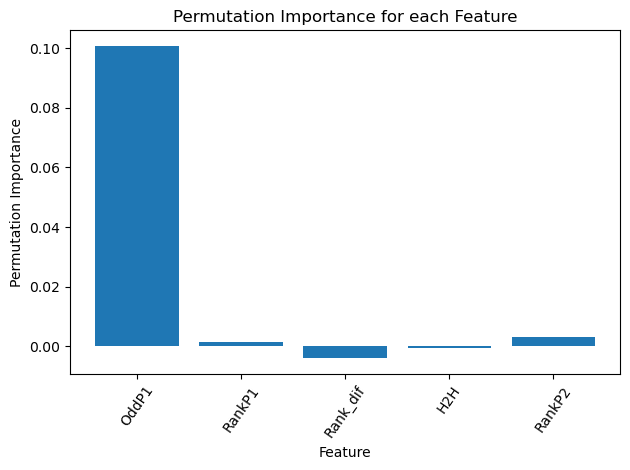

In [67]:
# Assuming trained_model is your KerasRegressor
result = permutation_importance(classifier, X_test, y_test, n_repeats=5, random_state=42)

# Get feature importances
importances = result.importances_mean

feature_names = X_train.columns

# Plot the feature importances
plt.barh(range(len(feature_names)), importances, tick_label=feature_names)  # Use barh for horizontal bars
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Permutation Importance for each Feature')
plt.tight_layout()
plt.savefig(f"../figures/{model}-permutation-importances-{today_date}.png")
plt.show()
plt.close()  # Close the plot to avoid saving additional figures


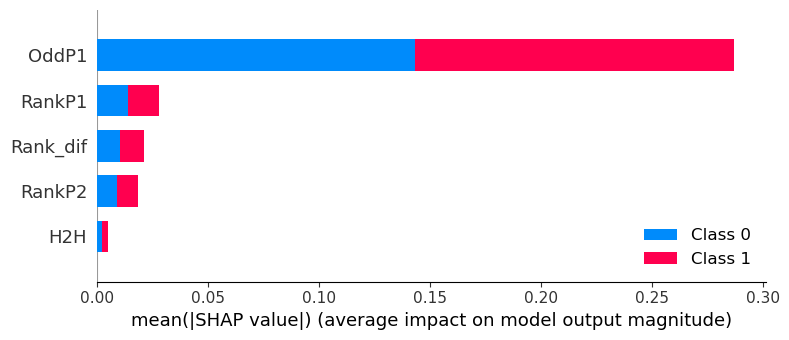

In [65]:
# Create a SHAP explainer object
explainer = shap.TreeExplainer(decision_tree)

# Calculate SHAP values for a set of instances (e.g., X_test)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type='bar')

# Force plot for a specific instance (e.g., the first instance)
shap.force_plot(explainer.expected_value[1], shap_values[1][0, :], X_test.iloc[0, :])

# Save the force plot as PNG
plt.savefig(f"../figures/{model}-shap-analysis.png")
plt.close()  # Close the plot to avoid saving additional figures


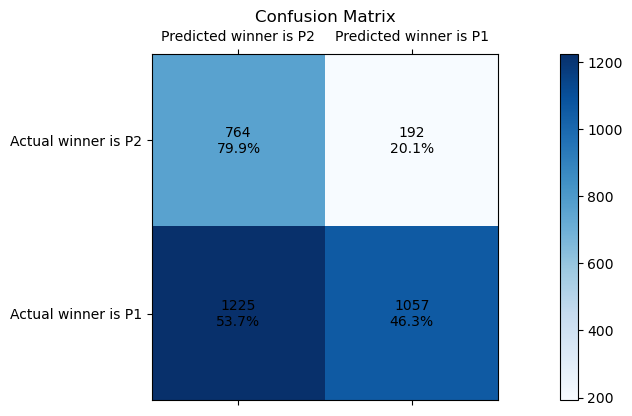

In [69]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate percentages for the confusion matrix
percentage_matrix = (conf_matrix.T / conf_matrix.sum(axis=1)).T * 100  # Calculate percentages for each row

# Create a figure and axes
fig, ax = plt.subplots(1, 1, figsize=(16, 4.5))

# Plot the confusion matrix
cax = ax.matshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Percentages')
plt.colorbar(cax)

# Annotate the cells with the percentage values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, '{}\n{:.1f}%'.format(conf_matrix[i, j], percentage_matrix[i, j]), ha='center', va='center')

# Add labels for clarity
plt.xticks(np.arange(conf_matrix.shape[1]), labels=['Predicted winner is P2', 'Predicted winner is P1'])
plt.yticks(np.arange(conf_matrix.shape[0]), labels=['Actual winner is P2', 'Actual winner is P1'])

plt.title('Confusion Matrix')
plt.savefig(f"../figures/{model}-confusion-matrix.png")
plt.show()
plt.close()

Random Forest Classifier

In [ ]:
# Define model type
classifier = RandomForestClassifier(random_state=42)

In [ ]:
# Grid search for hyperparameter tuning
param_grid = conf['random-forest']['param_grid']

In [ ]:
# Define model configurations
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    cv=conf['training']['cv'],
    scoring=custom_scorer,
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
# Print the best hyperparameters
print('Best Hyperparameters:', grid_search.best_params_)

best_params = grid_search.best_params_

In [ ]:
# Additional parameters (you may have other parameters like class_weight)
additional_params = {
    'random_state': 42
}

# Combine best_params and additional_params to create the final parameters
final_params = {**best_params, **additional_params}

# Create a decision tree classifier with the best parameters
classifier = RandomForestClassifier(**final_params)

In [ ]:
# Train the model on the training data
classifier.fit(X_train, y_train)

In [ ]:
# Make predictions on the test data
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Print the results
print('Accuracy:', accuracy)
print('Classification Report:\n', report)

In [ ]:
custom_profit(y_test, y_pred, X_test_and_aux_data['OddP1'], X_test_and_aux_data['OddP2'])

In [ ]:
# Assuming trained_model is your KerasRegressor
result = permutation_importance(classifier, X_test, y_test, n_repeats=10, random_state=42)

# Get feature importances
importances = result.importances_mean

feature_names = X_train.columns

# Plot the feature importances
plt.bar(range(len(feature_names)), importances, tick_label=feature_names)

plt.xticks(range(X_test.shape[1]), feature_names, rotation=55)
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.title('Permutation Importance for each Feature')
plt.tight_layout()
plt.savefig('permutation_importances.png')
plt.show()

In [ ]:
print(classifier)

In [ ]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate percentages for the confusion matrix
percentage_matrix = (conf_matrix.T / conf_matrix.sum(axis=1)).T * 100  # Calculate percentages for each row

# Create a figure and axes
fig, ax = plt.subplots(1, 1, figsize=(16, 4.5))

# Plot the confusion matrix
cax = ax.matshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Percentages')
plt.colorbar(cax)

# Annotate the cells with the percentage values
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, '{}\n{:.1f}%'.format(conf_matrix[i, j], percentage_matrix[i, j]), ha='center', va='center')

# Add labels for clarity
plt.xticks(np.arange(conf_matrix.shape[1]), labels=['Predicted winner is P2', 'Predicted winner is P1'])
plt.yticks(np.arange(conf_matrix.shape[0]), labels=['Actual winner is P2', 'Actual winner is P1'])

plt.title('{}: Confusion Matrix'.format(classifier))
plt.savefig('confusion-matrix.png')

In [ ]:
# Create a SHAP explainer object
explainer = shap.TreeExplainer(classifier)

# Calculate SHAP values for a set of instances (e.g., X_test)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type='bar')

# Force plot for a specific instance (e.g., the first instance)
shap.force_plot(explainer.expected_value[1], shap_values[1][0, :], X_test.iloc[0, :])

In [ ]:
rf_html_content = f'''
<!DOCTYPE html>
<html>
<body>
    <h2>Model: Random Forest</h2>
    <p>Tested parameters:</p>
    <ul>
        <li><strong>Criterion:</strong> {conf['random-forest']['param_grid']['criterion']}</li>
        <li><strong>Max Depth:</strong> {conf['random-forest']['param_grid']['max_depth']}</li>
        <li><strong>Min Samples Split:</strong> {conf['random-forest']['param_grid']['min_samples_split']}</li>
        <li><strong>Min Samples Leaf:</strong> {conf['random-forest']['param_grid']['min_samples_leaf']}</li>
    </ul>    
    <p>Best Hyperparameters:</p>
    <ul>
        <li><strong>N Estimators:</strong> {best_params['n_estimators']}</li>
        <li><strong>Max Depth:</strong> {best_params['max_depth']}</li>
        <li><strong>Min Samples Split:</strong> {best_params['min_samples_split']}</li>
        <li><strong>Min Samples Leaf:</strong> {best_params['min_samples_leaf']}</li>
    </ul>
    <h3>Profit: {profit.sum():.2f}</h3>
</body>
</html>
'''

In [70]:
today_date = datetime.now().strftime('%Y-%m-%d')

# Save configs tested and results in an HTML report
report_path = '../features-{}-training-report-{}.html'.format(model, today_date)

In [101]:
# Add custom CSS styling for spacing between cells
custom_style = '<style>td, th { padding: 8px; }</style>'

# convert df to html table  
html_df = dataset.describe().to_html(float_format='%.2f', classes='table', border=0, justify='center')
html_dataset = f'{custom_style}{html_df}'

# convert df to html table  
html_df = X_train.describe().to_html(float_format='%.2f', classes='table', border=0, justify='center')
html_X_train = f'{custom_style}{html_df}'

# create table for param_grid
html_table = '<table border="1">\n'

# Header row
html_table += '<tr>'
html_table += '<th>Key</th><th>Tested Hyperparameters</th><th>Best Hyperparameter</th>'
html_table += '</tr>\n'

# Data rows
for key, value in conf[model]['param_grid'].items():
    additional_value = best_params.get(key, '')
    html_table += '<tr>'
    html_table += f'<td>{key}</td><td>{value}</td><td>{additional_value}</td>'
    html_table += '</tr>\n'

html_table += '</table>'
html_param_grid = html_table

html_content = f'''
<!DOCTYPE html>
<html>
<head>
    <title>Training Report - {model} - {today_date}</title>
</head>
<body>
    <h3>Dataset: ../features.pkl </h3>
    <h3>Dataset Summary</h3>
    <ul>{html_dataset}<ul>
    <h3>Features Summary</h3>
        <ul>{html_X_train}</ul>
        <img src="../reports/figures/{model}-permutation-importances.png" alt="Permutation Importances">
    </ul>
    <h4>Training</h4>
    <p>Tested Hyperparameters: {html_param_grid}</p>   
    <h3>Results</h3>
    <h4>Profit: {profit.sum():.2f}</h4>
</body>
</html>
'''

# Write the HTML content to the file
with open(report_path, 'w') as report_file:
    report_file.write(html_content)

print(f"Training report saved to: {report_path}")

Training report saved to: ../decision-tree-training-report-2024-01-02.html
